# Tensile Test: from machine file to RDF

> **This is notebook 2 of 2.** It assumes you have already worked through
> [Notebook 1](1_tensile_test_workflow.ipynb), which explains the schema
> structure, the OO-LD format, and SHACL validation using a hand-crafted
> input file. Here, the same pipeline runs end-to-end from a real instrument
> export, with no manual data entry required.

**You only need to edit one cell:** Step 0 below. Everything else is automatic.

**What you get back:**
- An RDF graph with test metadata (conditions, standard, temperature) and
  typed column descriptors, ready to publish to a knowledge graph
- A pandas DataFrame with the full time-series data, ready to plot or analyse

The measurement *values* never become RDF triples. Only the column
descriptors (ontology class and unit) are stored in the graph. This keeps the
graph compact while making the data findable and self-describing.

```
Instrument export file
  │
  ├─ metadata rows  ──► Transformer ──► OO-LD ──► RDF graph
  │                     (same transform as notebook 1)
  └─ data rows  ─────► pandas DataFrame
```

## Supported file format

This notebook uses the **testXpert III parser** for Zwick/Roell instruments.
For other instruments, swap in a different parser; the rest of the notebook
stays unchanged. See `semantic-transformers/src/semantic_transformers/parsers/`
for available parsers and `docs/2_adding-a-parser.md` for how to add one.

## Environment setup

If you are viewing this notebook on GitHub and want to run it locally, clone
the repository first so that all schema files and example inputs are present:

```bash
git clone https://github.com/Semantic-Dataspace/semantic-schemas.git
cd semantic-schemas
```

Then create a virtual environment and start Jupyter:

```bash
python3 -m venv .venv
source .venv/bin/activate
pip install semantic-schemas semantic-transformers jupyterlab
jupyter lab
```

Open this notebook from the `docs/` subfolder inside JupyterLab.

In [1]:
# Install dependencies (run once; skip if already installed)
%pip install -q semantic-schemas semantic-transformers

Note: you may need to restart the kernel to use updated packages.


In [2]:
import json, pathlib, rdflib
from importlib.metadata import version
from semantic_schemas import Schema

HERE      = pathlib.Path().resolve()             # docs/
SCHEMA    = HERE.parent                          # tensile-test/TTO/
SCHEMAS   = SCHEMA.parents[3]                    # schemas/
CHAR_BASE = SCHEMAS / "characterization" / "step" / "base" / "PMDCo"

tto_schema  = Schema(SCHEMA)
base_schema = Schema(CHAR_BASE)

print("rdflib  ", version("rdflib"))

from semantic_transformers import Transformer
from semantic_transformers.parsers.characterization.tensile_test.testxpert_iii import TestXpertIIIParser

print("semantic-transformers", version("semantic-transformers"))

# Example test file in same directory as this notebook
csv_file = HERE / 'example_tensile_test.TXT'

rdflib   7.6.0


semantic-transformers 0.1.0


## Step 0: Point to your file

Edit the lines below and run all cells. That is all that is needed for a basic run.

| Variable | What to put here |
|---|---|
| `csv_file` | Path to your Zwick export (`.TXT` or `.csv`) |
| `BASE_IRI` | Base IRI for this dataset; replace with your own namespace |

`test_name` is optional, if omitted the file name is used.

In [3]:
test_name = None   # optional; set to a string to override the file-name default

# Base IRI for this dataset. Relative node IDs (test instance, conditions,
# timeseries dataset) are resolved against this IRI. Replace with your own
# namespace in production, e.g. "https://your-institute.org/tests/".
BASE_IRI = "https://example.org/"

print(f"Using example test file: {csv_file.name}")
print(f"File exists: {csv_file.exists()}")
print(f"Data base IRI: {BASE_IRI}")

Using example test file: example_tensile_test.TXT
File exists: True
Data base IRI: https://example.org/


## Step 1: Parse, transform, and build the RDF graph

The `Transformer` does three things in one call:

1. **Parse**: the Zwick parser reads the export file, separates the metadata
   block from the time-series rows, and maps the metadata to the simplified
   JSON format the schema transform expects.
2. **Transform**: the JSONata expression in `specs/transform.simplified.jsonata`
   converts the simplified JSON into an OO-LD document following the TTO
   measurement pattern.
3. **Build RDF**: the OO-LD document is parsed into an RDF graph; one
   lightweight descriptor node per measurement column is also added.

| JSON field | Ontology IRI |
|---|---|
| `type` (process) | `rdf:type` → `pmdco:PMD_0000974` |
| `has_specified_input` | `OBI_0000293` |
| `has_process_attribute` | `pmdco:PMD_0000009` → condition quality nodes |
| `result_value` | `pmdco:PMD_0000006` typed `xsd:float` |
| `result_unit` | `IAO_0000039` → QUDT unit IRI |

In [4]:
transformer = Transformer(
    parser          = TestXpertIIIParser(),
    semantic_schema = SCHEMA,
)

overrides = {}
if test_name:
    overrides['test_name'] = test_name

result = transformer.run(csv_file, base=BASE_IRI, **overrides)

print('OO-LD document (intermediate):')
print(json.dumps(result.oold_doc, indent=2))

OO-LD document (intermediate):
{
  "conforms_to": "https://github.com/semantic-dataspace/semantic-schemas/tree/main/schemas/characterization/step/tensile-test/TTO/#v3.0.0",
  "type": "pmdco:PMD_0000974",
  "id": "tensile-test-example-tensile-test",
  "label": "example_tensile_test",
  "realizes": [
    {
      "type": "tto:TTO_0000054",
      "id": "tensile-test-example-tensile-test-method",
      "label": "ISO 6892-1"
    }
  ],
  "has_specified_input": [],
  "date": "2021-05-19T09:36:00",
  "has_process_attribute": [
    {
      "type": "tto:TTO_0000051",
      "id": "tensile-test-example-tensile-test-strain-rate",
      "is_quality_measured_as": "tensile-test-example-tensile-test-strain-rate-smd"
    },
    {
      "type": "pmdco:PMD_0000967",
      "id": "tensile-test-example-tensile-test-temperature",
      "is_quality_measured_as": "tensile-test-example-tensile-test-temperature-smd"
    }
  ],
  "measured_properties": [
    {
      "type": "obo:IAO_0000109",
      "id": "tensile-

## Step 2: Explore the time-series data

The raw measurement columns are in `result.dataframe`, a standard pandas
DataFrame. You can plot, filter, or compute derived quantities (yield strength,
Young's modulus, …) using any tool you like.

In [5]:
df = result.dataframe
print(f'{len(df)} rows  ×  {len(df.columns)} columns\n')
print(df.head(10).to_string(index=False))

82 rows  ×  6 columns

 Prüfzeit  Standardkraft  Traversenweg absolut  Standardweg  Breitenänderung  Dehnung
      0.0            0.0                 0.000        0.000           -0.000     0.00
      0.1          807.6                 0.011        0.010           -0.001     0.01
      0.2         1615.2                 0.023        0.020           -0.001     0.02
      0.3         2422.8                 0.034        0.030           -0.002     0.04
      0.5         3230.4                 0.045        0.040           -0.003     0.05
      0.6         4038.1                 0.056        0.050           -0.004     0.06
      0.7         4845.7                 0.068        0.059           -0.004     0.07
      0.8         5653.3                 0.079        0.069           -0.005     0.09
      0.8         5721.1                 0.081        0.071           -0.005     0.09
      0.8         5032.0                 0.082        0.073           -0.006     0.09


In [6]:
# Semantic annotations stored in the graph, one row per measurement column
print(f'{"Column":<25}  {"Ontology class":<50}  QUDT unit')
print('-' * 100)
for col in df.columns:
    iri  = result.column_iris.get(col) or '—'  # None for columns with no TTO class
    unit = result.column_units.get(col, '—')
    print(f'{col:<25}  {iri:<50}  {unit}')


Column                     Ontology class                                      QUDT unit
----------------------------------------------------------------------------------------------------
Prüfzeit                   —                                                   http://qudt.org/vocab/unit/SEC
Standardkraft              —                                                   http://qudt.org/vocab/unit/N
Traversenweg absolut       https://w3id.org/pmd/tto/TTO_0000013                http://qudt.org/vocab/unit/MilliM
Standardweg                https://w3id.org/pmd/tto/TTO_0000005                http://qudt.org/vocab/unit/MilliM
Breitenänderung            https://w3id.org/pmd/tto/TTO_0000011                http://qudt.org/vocab/unit/MilliM
Dehnung                    https://w3id.org/pmd/tto/TTO_0000004                http://qudt.org/vocab/unit/PERCENT


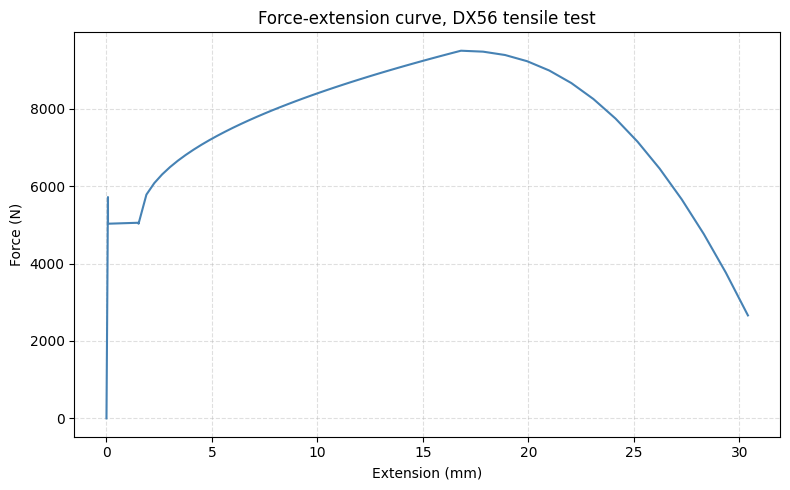

In [7]:
import matplotlib.pyplot as plt

# result.column_iris maps each column name to its TTO v3.0.0 ontology IRI (or None).
# Invert the mapping to look up columns by IRI; skip entries with no TTO class.
TTO = "https://w3id.org/pmd/tto/"
col_by_iri = {iri: col for col, iri in result.column_iris.items() if iri}

x_col = col_by_iri[TTO + "TTO_0000005"]   # extension — tto:TTO_0000005 (Standardweg)
# Test force has no TTO v3.0.0 numeric class; find it by unit (N) instead.
y_col = next(
    (c for c, u in result.column_units.items() if u.endswith("/N")),
    "Standardkraft",
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df[x_col], df[y_col], color="steelblue", linewidth=1.5)
ax.set_xlabel("Extension (mm)")
ax.set_ylabel("Force (N)")
ax.set_title("Force-extension curve, DX56 tensile test")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


## Step 3: Inspect the RDF graph

The graph contains:
- The tensile test process node typed to `pmdco:PMD_0000974`
- Process conditions (standard, temperature, strain rate) via `pmdco:PMD_0000009`
- A `csvw:Table` node for the time series, linked via `obi:OBI_0000299`
- One `csvw:Column` descriptor node per measurement column, with an optional
  additional TTO v3.0.0 numeric class IRI (e.g. `tto:TTO_0000005` for extension)
  and a unit IRI via `obo:IAO_0000039`


In [8]:
flat = result.flat_graph

print(f'Graph contains {len(flat)} triples.\n')
print(flat.serialize(format='turtle'))

Graph contains 67 triples.

@prefix csvw: <http://www.w3.org/ns/csvw#> .
@prefix dcterms: <http://purl.org/dc/terms/> .
@prefix obo: <http://purl.obolibrary.org/obo/> .
@prefix pmdco: <https://w3id.org/pmd/co/> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix tto: <https://w3id.org/pmd/tto/> .
@prefix unit: <http://qudt.org/vocab/unit/> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

<https://example.org/tensile-test-example-tensile-test> a pmdco:PMD_0000974 ;
    rdfs:label "example_tensile_test" ;
    obo:BFO_0000055 <https://example.org/tensile-test-example-tensile-test-method> ;
    obo:OBI_0000299 <https://example.org/tensile-test-example-tensile-test-strain-rate-smd>,
        <https://example.org/tensile-test-example-tensile-test-temperature-smd>,
        <https://example.org/tensile-test-example-tensile-test/timeseries> ;
    dcterms:conformsTo <https://github.com/semantic-dataspace/semantic-schemas/tree/main/schemas/characterization/step/tensile-test/TTO/

## Step 4: Validate against SHACL shapes

The TTO schema is self-contained. The shape in `specs/shape.ttl` validates the
process node, datum nodes, and value specifications.

> **Note**: if you have not provided a specimen IRI (see the Advanced section
> at the bottom of this notebook), the SHACL result will flag a missing
> `has_specified_input`. This is expected for a basic run; add a specimen IRI
> before publishing to a knowledge graph.

In [9]:
conforms, violations = tto_schema.validate(flat, also=[base_schema])

print(f"Conforms: {conforms}")
for v in violations:
    print(f"  {v}")

Conforms: False
  A TensileTestingProcess must have at least one has_specified_input (the specimen IRI).  [OBI_0000293]
  has_specified_output (OBI_0000299) must point to ScalarMeasurementDatum nodes (IAO_0000109).  [OBI_0000299]


## Step 5: Query the graph

SPARQL is the query language for RDF graphs. The query below extracts the
test metadata and measurement column annotations directly from the graph. You do not need to understand SPARQL to read the output.

This is the same query pattern used in the cross-domain workflow notebook to
inspect tensile test results across a combined graph.

In [10]:
PMDCO = rdflib.Namespace('https://w3id.org/pmd/co/')

proc_iri = next(flat.subjects(rdflib.RDF.type, PMDCO['PMD_0000974']), None)
if proc_iri:
    print(f'Test IRI : {proc_iri}')
    print(f'Label    : {flat.value(proc_iri, rdflib.RDFS.label)}')
else:
    print('No PMD_0000974 process node found in graph.')

print()

# Measurement column annotations stored in the graph
SPARQL_COLS = """
PREFIX csvw: <http://www.w3.org/ns/csvw#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX iao:  <http://purl.obolibrary.org/obo/IAO_>

SELECT ?column ?type ?unit
WHERE {
  ?tbl a csvw:Table ; csvw:column ?col .
  ?col a csvw:Column ; rdfs:label ?column .
  OPTIONAL { ?col a ?type . FILTER(?type != csvw:Column) }
  OPTIONAL { ?col iao:0000039 ?unit . }
}
ORDER BY ?column
"""

rows = list(flat.query(SPARQL_COLS))
if rows:
    print(f'{"Column":<25}  {"Ontology class":<50}  Unit')
    print('-' * 100)
    for r in rows:
        col  = str(r.column)
        typ  = str(r.type).rsplit('/', 1)[-1].rsplit('#', 1)[-1] if r.type else '—'
        unit = str(r.unit).rsplit('/', 1)[-1] if r.unit else '—'
        print(f'{col:<25}  {typ:<50}  {unit}')
else:
    print('No column annotation nodes found.')


Test IRI : https://example.org/tensile-test-example-tensile-test
Label    : example_tensile_test



Column                     Ontology class                                      Unit
----------------------------------------------------------------------------------------------------
Breitenänderung            TTO_0000011                                         MilliM
Dehnung                    TTO_0000004                                         PERCENT
Prüfzeit                   —                                                   SEC
Standardkraft              —                                                   N
Standardweg                TTO_0000005                                         MilliM
Traversenweg absolut       TTO_0000013                                         MilliM


## Step 6: Save

Both outputs are saved next to this notebook:

| File | Contents |
|---|---|
| `<stem>.ttl` | RDF graph, metadata and column descriptors |
| `<stem>.parquet` | Full time-series DataFrame |

Before serializing the RDF, the source CSV filename is written into the graph
as `csvw:url` on the `csvw:Table` node (the canonical CSVW predicate for a
table's URL), and the Parquet path as `dcat:downloadURL`.  Both are resolved
against a configurable `BASE_IRI` URL.  Any system that later reads the TTL
can navigate from the test IRI directly to the raw data:

```sparql
PREFIX obi:  <http://purl.obolibrary.org/obo/OBI_>
PREFIX csvw: <http://www.w3.org/ns/csvw#>
PREFIX dcat: <http://www.w3.org/ns/dcat#>

SELECT ?source ?download
WHERE {
  ?test obi:0000299 ?tbl .
  ?tbl a csvw:Table .
  OPTIONAL { ?tbl csvw:url         ?source   . }
  OPTIONAL { ?tbl dcat:downloadURL ?download . }
}
```


In [11]:
stem = pathlib.Path(csv_file).stem

ttl_path     = HERE / f'{stem}.ttl'
parquet_path = HERE / f'{stem}.parquet'

# Register the source CSV (csvw:url) and Parquet (dcat:downloadURL) on the
# csvw:Table node, resolved against BASE_IRI defined in Step 0.
CSVW = rdflib.Namespace("http://www.w3.org/ns/csvw#")
DCAT = rdflib.Namespace("http://www.w3.org/ns/dcat#")
table_node = next(flat.subjects(rdflib.RDF.type, CSVW.Table), None)
if table_node:
    flat.add((table_node, CSVW.url,
              rdflib.URIRef(BASE_IRI + pathlib.Path(csv_file).name)))
    flat.add((table_node, DCAT.downloadURL,
              rdflib.URIRef(BASE_IRI + parquet_path.name)))

flat.serialize(destination=str(ttl_path), format='turtle')
print(f'RDF written to      {stem}.ttl')

try:
    df.to_parquet(parquet_path, index=False)
    print(f'DataFrame written to {stem}.parquet')
except ImportError:
    csv_path = HERE / f'{stem}_timeseries.csv'
    df.to_csv(csv_path, index=False)
    print(f'DataFrame written to {stem}_timeseries.csv  (install pyarrow for Parquet)')


RDF written to      example_tensile_test.ttl
DataFrame written to example_tensile_test.parquet


## Summary

| Step | What happens |
|---|---|
| 0 | You point to your file |
| 1 | The testXpert III parser reads the file; the Transformer maps metadata to RDF |
| 2 | The time-series DataFrame is ready for analysis and plotting |
| 3 | The RDF graph shows the semantic structure |
| 4 | SHACL validation confirms structural correctness |
| 5 | SPARQL query shows the column annotations stored in the graph |
| 6 | Source CSV and Parquet paths registered in graph; both files saved |

---

## Advanced: linking to a specimen

In a knowledge graph, a tensile test is linked to the specimen it consumed.
This link, the `specimen_iri`, is an identifier that must already exist in
your knowledge graph before you can reference it here.

If you have registered your specimen and know its IRI, add it to the
overrides dict in Step 1:

```python
result = transformer.run(
    csv_file,
    specimen_iri = 'https://your-instance.org/specimens/my-specimen-1',
)
```

Without a `specimen_iri`, the graph is structurally valid for exploration but
the SHACL validation will flag a missing `has_specified_input`.
Add a real IRI before publishing to a triple store.

---

## Using a different testXpert III file variant

testXpert III software versions and machine templates vary: the metadata block
may have a different number of rows, use different label strings, or be
localised to another language. You do not need to edit Python to handle these
differences.

Create a small config YAML describing how your file differs from the default:

```yaml
# parser_config.yaml
metadata_rows: 15            # rows before the column-header row (default: 20)
strain_rate_label: null      # null = skip; default is "Prüfgeschwindigkeit"
meta_field_map:
  Temperature: temperature
  Standard:    test_standard
  Speed:       strain_rate
```

Then pass it to the `Transformer` in Step 1:

```python
transformer = Transformer(
    parser          = TestXpertIIIParser.from_config("parser_config.yaml"),
    semantic_schema = SCHEMA,
)
```

The same options are available as keyword arguments if you prefer not to use
a separate file:

```python
transformer = Transformer(
    parser = TestXpertIIIParser(
        metadata_rows  = 15,
        meta_field_map = {"Temperature": "temperature"},
    ),
    semantic_schema = SCHEMA,
)
```

---

## Using a different machine entirely

If your machine exports a fundamentally different file format, you need a new
parser. Copy an existing parser from
`src/semantic_transformers/parsers/characterization/tensile_test/`,
override `_parse_metadata()` and `_parse_timeseries()` for your file
structure, then swap it in:

```python
from semantic_transformers.parsers.<domain>.<specialisation>.<machine> import MyParser

transformer = Transformer(
    parser          = MyParser(),
    semantic_schema = SCHEMA,
)
```

The schema transform and all notebook steps remain unchanged.
See `semantic-transformers/docs/2_adding-a-parser.md` for the full guide.

---

## Further reading

- [TTO repository](https://github.com/materialdigital/tensile-test-ontology): reference data and ontology
- [PMDCo measurement pattern](https://github.com/materialdigital/core-ontology/tree/main/patterns/measurement)
- [Tensile Test (PMDCo)](../../PMDCo/README.md): the label-based variant of this schema
- [semantic-transformers](../../../../semantic-transformers/): the library powering this notebook
- [OO-LD primer](../../../../docs/2_oold-primer.md): what OO-LD is and how it works
- [Schema format reference](../../../../docs/3_schema-format.md): folder structure and naming conventions
